# Session 5 — Alternative Activation Functions

This notebook is an independently structured practice notebook exploring:
1. Leaky ReLU
2. PReLU
3. Softmax
4. Hard Sigmoid
5. Choosing activation functions for different neural-network layers

The examples use different values and organization so the focus is on understanding and experimentation.

## 1. Exploring Leaky ReLU

Leaky ReLU keeps a small negative slope instead of making every negative input exactly zero.

In [1]:
import numpy as np

def leaky_relu(values, negative_slope=0.08):
    values = np.asarray(values, dtype=float)
    return np.where(values >= 0, values, negative_slope * values)

inputs = np.array([-6, -3, -1, 0, 1, 3, 6])
activated = leaky_relu(inputs)

print("Input values :", inputs)
print("Leaky ReLU  :", np.round(activated, 3))

Input values : [-6 -3 -1  0  1  3  6]
Leaky ReLU  : [-0.48 -0.24 -0.08  0.    1.    3.    6.  ]


**What to notice:** unlike ordinary ReLU, negative inputs are not completely discarded. The parameter `negative_slope` controls how much of the negative signal remains.

## 2. Comparing ReLU, Leaky ReLU and PReLU

PReLU makes the negative slope a parameter that can be learned during training.

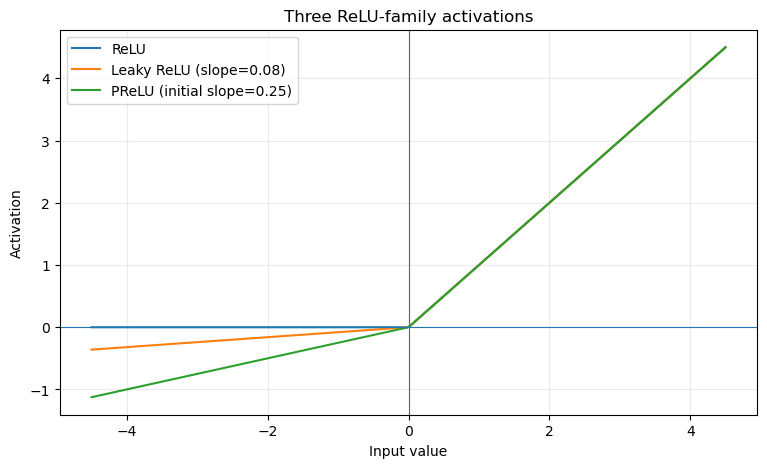

In [2]:
import matplotlib.pyplot as plt

def relu(values):
    return np.maximum(values, 0)

def leaky(values, slope=0.08):
    return np.where(values >= 0, values, slope * values)

def prelu(values, slope=0.25):
    return np.where(values >= 0, values, slope * values)

axis = np.linspace(-4.5, 4.5, 300)

plt.figure(figsize=(9, 5))
plt.plot(axis, relu(axis), label="ReLU")
plt.plot(axis, leaky(axis), label="Leaky ReLU (slope=0.08)")
plt.plot(axis, prelu(axis), label="PReLU (initial slope=0.25)")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Input value")
plt.ylabel("Activation")
plt.title("Three ReLU-family activations")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

**Comparison:** ReLU has a zero negative branch, Leaky ReLU uses a fixed small slope, and PReLU can use a tunable slope. This makes the three functions behave differently for negative inputs while sharing the same positive-side behavior.

## 3. Softmax for Multi-Class Scores

Softmax converts a collection of raw scores into values that behave like a probability distribution.

In [3]:
def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)   # improves numerical stability
    exp_scores = np.exp(shifted)
    return exp_scores / exp_scores.sum()

class_scores = np.array([3.4, 1.2, 2.1, -0.5, 0.7])
class_probabilities = softmax(class_scores)

labels = ["Cat", "Dog", "Horse", "Bird", "Rabbit"]

for label, score, probability in zip(labels, class_scores, class_probabilities):
    print(f"{label:>7} | score = {score:>4.1f} | probability = {probability:.4f}")

print("\nProbability sum:", class_probabilities.sum())

    Cat | score =  3.4 | probability = 0.6799
    Dog | score =  1.2 | probability = 0.0753
  Horse | score =  2.1 | probability = 0.1853
   Bird | score = -0.5 | probability = 0.0138
 Rabbit | score =  0.7 | probability = 0.0457

Probability sum: 1.0


**Observation:** the probabilities add up to approximately 1. The class with the largest input score receives the largest probability, although the other classes can still receive non-zero probabilities.

## 4. Hard Sigmoid

Hard Sigmoid is a piecewise-linear approximation of sigmoid. Here the output is clipped to the range 0–1.

In [4]:
def hard_sigmoid(value):
    value = np.asarray(value, dtype=float)
    return np.clip(0.2 * value + 0.5, 0, 1)

trial_inputs = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)
trial_outputs = hard_sigmoid(trial_inputs)

print("Input   Hard Sigmoid")
print("--------------------")
for inp, out_value in zip(trial_inputs, trial_outputs):
    print(f"{inp:>5.1f}      {out_value:.2f}")

Input   Hard Sigmoid
--------------------
 -5.0      0.00
 -2.0      0.10
 -1.0      0.30
  0.0      0.50
  1.0      0.70
  2.0      0.90
  5.0      1.00


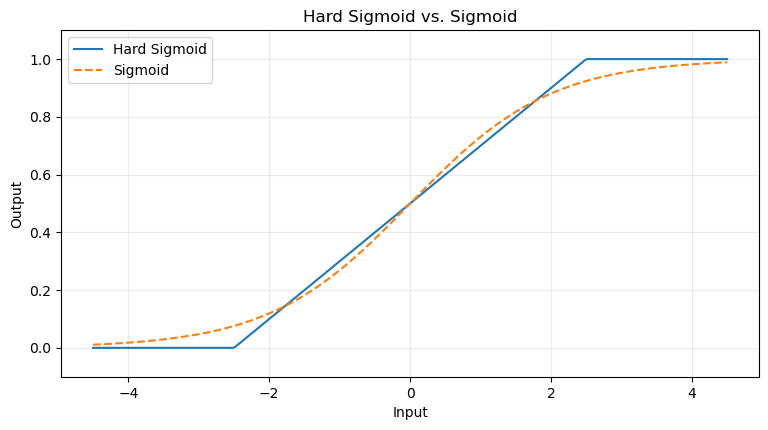

In [5]:
plt.figure(figsize=(9, 4.5))
plt.plot(axis, hard_sigmoid(axis), label="Hard Sigmoid")
plt.plot(axis, 1 / (1 + np.exp(-axis)), label="Sigmoid", linestyle="--")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Hard Sigmoid vs. Sigmoid")
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

**Observation:** Hard Sigmoid has flat regions and a straight-line middle region. It is simpler than the standard sigmoid and can be useful when a less expensive approximation is desirable.

## 5. Choosing an Activation for Different Layers

### Hidden layers
**Typical choice:** ReLU or a ReLU variant.

**Reason:** ReLU is simple and avoids the strong saturation behavior seen in sigmoid/tanh on the positive side. Leaky ReLU or PReLU can be considered when maintaining a non-zero negative-side slope is useful.

### Output layer — one of several mutually exclusive classes
**Typical choice:** Softmax.

**Reason:** Softmax produces a set of non-negative values whose sum is 1, which fits a single-choice multi-class prediction.

### Output layer — binary prediction
**Typical choice:** Sigmoid.

**Reason:** A single sigmoid output can represent a value between 0 and 1, which is convenient for a binary probability.

### Final note
There is no single activation function that is best for every layer. The correct choice depends on the role of the layer and the type of prediction being made.